# Housekeeping notes
- new analysis all coming from laser on datapoints
- all coming from one file instead of 12 separate for each clover

# Setup Code

In [3]:
# Import Packages
import Pkg

Pkg.add("Plots")
Pkg.add("LsqFit")
Pkg.add("DelimitedFiles")
Pkg.add("PlotlyJS")  # optional if you later want interactive plots
Pkg.add("LaTeXStrings")

using Pkg
Pkg.add(["CSV", "DataFrames"])
using CSV, DataFrames

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Project.toml`
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Project.toml`
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Project.toml`
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Project.toml`
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Project.toml`
  No Changes to `~/Desktop/Research/Madurga/VITO-ENiGMA/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/Research/M

In [4]:
using Plots,DelimitedFiles,LsqFit,LaTeXStrings

include("src/PhotoPeakFit.jl");

default(framestyle=:box,
        mc=:black,
        grid=false,
        guidefont=14,
        tickfont=12,
        lc=:navy,
        xlabel="Eᵧ (internal)",
        ylabel="counts")

In [5]:
kliterature = [564.79,
               586.01,
               2013.45]

3-element Vector{Float64}:
  564.79
  586.01
 2013.45

In [6]:
# Uploading and grouping data by clover
raw_data = readdlm("laserOn.txt", comments=true)


data = DataFrame(raw_data, [:x_center, :y_center, :content])


grouped_data = groupby(data, :y_center)


Row,x_center,y_center,content
,Float64,Float64,Float64
1,0.5,0.5,175084.0
2,1.5,0.5,4210.0
3,2.5,0.5,764.0
4,3.5,0.5,1926.0
5,4.5,0.5,2874.0
6,5.5,0.5,3974.0
7,6.5,0.5,4643.0
8,7.5,0.5,5987.0
9,8.5,0.5,6722.0


# Calibration Data
- I was told this file was given to me pre-calibrated, so don't need anything here
- Spot for calibration setup if I'm wrong

### Efficiency stuff

In [79]:
io = open("calibrations/Eu152-efficiency-cal.csv", "r")
clover_eff_params = readdlm(io, ',', Float64, '\n', comments=true, comment_char='#')
close(io)

c0_eff_fit, c1_eff_fit, c2_eff_fit = clover_eff_params[1,:],clover_eff_params[2,:],clover_eff_params[3,:]

c0_eff_params,c1_eff_params,c2_eff_params = [c0_eff_fit[1],c0_eff_fit[3],c0_eff_fit[5]],
                                            [c1_eff_fit[1],c1_eff_fit[3],c1_eff_fit[5]],
                                            [c2_eff_fit[1],c2_eff_fit[3],c2_eff_fit[5]]

c0_σeff,c1_σeff,c2_σeff = [c0_eff_fit[2],c0_eff_fit[4],c0_eff_fit[6]], 
                          [c1_eff_fit[2],c1_eff_fit[4],c1_eff_fit[6]],
                          [c2_eff_fit[2],c2_eff_fit[4],c2_eff_fit[6]]

([0.04994475356378319, 0.03881764706440051, 0.0074349631904078745], [0.059208192080767955, 0.0466367978146129, 0.009090355673327628], [0.048188710602606065, 0.03712260347339793, 0.007054630479249403])

# Clover 0

## Crystal 0 (c0c0)

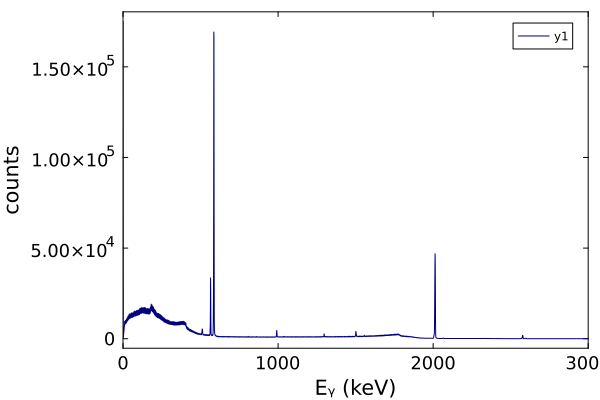

In [7]:
kc0c0 = Matrix(select(data[data.y_center .== 0.5, :], Not(:y_center)))

plot(kc0c0[:,1],kc0c0[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 16623.17700023051(17456.002155965798)
P2 = -25.65628332381801(30.848150808016094)
P3 = 86695.57316754783(2102.821186616833)
P4 = 564.7404350533753(0.02545521375918048)
P5 = 1.0849445081215197(0.02706768919869217)
Calibrated - Expected = -0.04956494662462774 keV


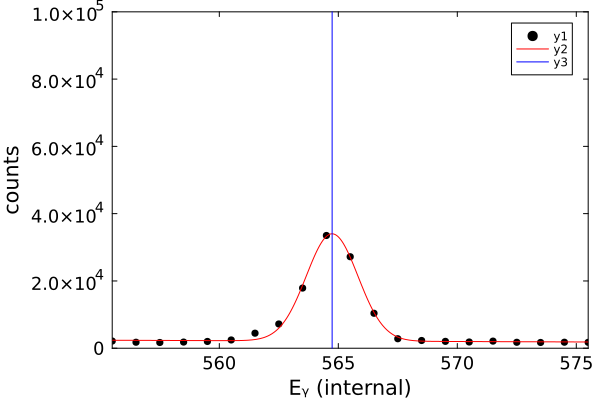

In [8]:
c0c0_p1_mean = 565.5

c0c0_x1low,c0c0_x1high=c0c0_p1_mean-10,c0c0_p1_mean+10; ylow,yhigh=0,1.0e5
c0c0_param1=[100,0.05,2e5,c0c0_p1_mean,1.0]
    # deos anything here need to be changed/adjusted (how so?)

c0c0_p1,c0c0_s1,f=PhotopeakFit.gaussianfit(kc0c0,c0c0_x1low,c0c0_x1high,c0c0_param1)

for (i,val) in enumerate(c0c0_p1)
    println("P$i = ",val,"($(c0c0_s1[i]))")
end
println("Calibrated - Expected = $(c0c0_p1[4] - kliterature[1]) keV")

scatter(kc0c0[:,1],kc0c0[:,2],xlims=(c0c0_x1low,c0c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c0_p1),c0c0_x1low,c0c0_x1high,lc=:red)
vline!([c0c0_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 86593.8135131415(17456.002155965798)
P2 = -141.5536924487184(30.848150808016094)
P3 = 497197.1151202344(2102.821186616833)
P4 = 585.9470233499326(0.02545521375918048)
P5 = 1.087737664674325(0.02706768919869217)
Calibrated - Expected = -0.06297665006741227 keV


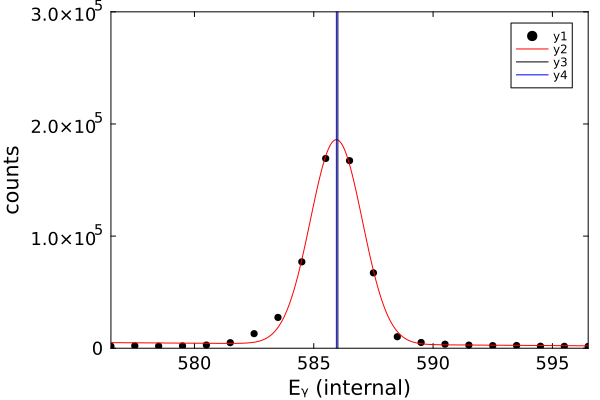

In [9]:
c0c0_p2_mean = 586.5
c0c0_x1low,c0c0_x1high=c0c0_p2_mean-10,c0c0_p2_mean+10; ylow,yhigh=0,300000
c0c0_param1=[100,0.05,2e5,c0c0_p2_mean,1.0]

c0c0_p2,c0c0_s2,f=PhotopeakFit.gaussianfit(kc0c0,c0c0_x1low,c0c0_x1high,c0c0_param1)

for (i,val) in enumerate(c0c0_p2)
    println("P$i = ",val,"($(c0c0_s1[i]))")
end
println("Calibrated - Expected = $(c0c0_p2[4] - kliterature[2]) keV")

scatter(kc0c0[:,1],kc0c0[:,2],xlims=(c0c0_x1low,c0c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c0_p2),c0c0_x1low,c0c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c0_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 246600.90397569147(17456.002155965798)
P2 = -122.06439601388077(30.848150808016094)
P3 = 210103.4898874613(2102.821186616833)
P4 = 2012.586820087952(0.02545521375918048)
P5 = 1.7736526292412194(0.02706768919869217)
Calibrated - Expected = -0.8631799120480537 keV


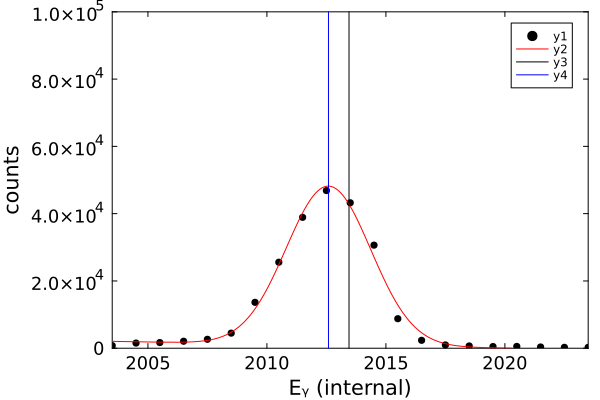

In [10]:
c0c0_p3_mean = 2013.5
c0c0_x1low,c0c0_x1high=c0c0_p3_mean-10,c0c0_p3_mean+10; ylow,yhigh=0,1e5
c0c0_param1=[100,0.05,2e5,c0c0_p3_mean,1.0]

c0c0_p3,c0c0_s3,f=PhotopeakFit.gaussianfit(kc0c0,c0c0_x1low,c0c0_x1high,c0c0_param1)

for (i,val) in enumerate(c0c0_p3)
    println("P$i = ",val,"($(c0c0_s1[i]))")
end
println("Calibrated - Expected = $(c0c0_p3[4] - kliterature[3]) keV")

scatter(kc0c0[:,1],kc0c0[:,2],xlims=(c0c0_x1low,c0c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c0_p3),c0c0_x1low,c0c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c0_p3[4]],lc=:blue)

## Crystal 1 (c0c1)

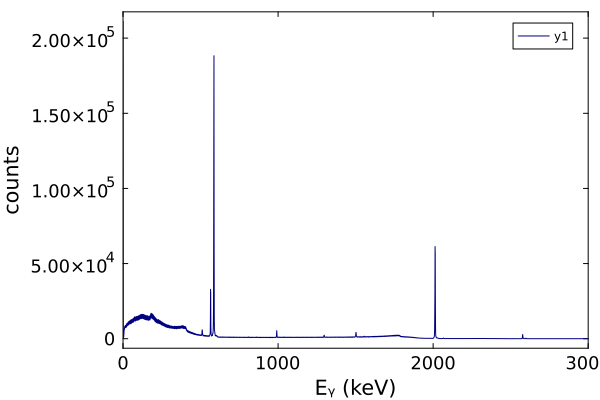

In [11]:
kc0c1 = Matrix(select(data[data.y_center .== 1.5, :], Not(:y_center)))

plot(kc0c1[:,1],kc0c1[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 10493.976468864947(16309.598796288263)
P2 = -14.345198573564648(28.82797872529627)
P3 = 77964.43970032844(1767.1662850351322)
P4 = 564.8779829924907(0.020597375318193934)
P5 = 0.9186850883235048(0.022174682272114894)
Calibrated - Expected = 0.08798299249076535 keV


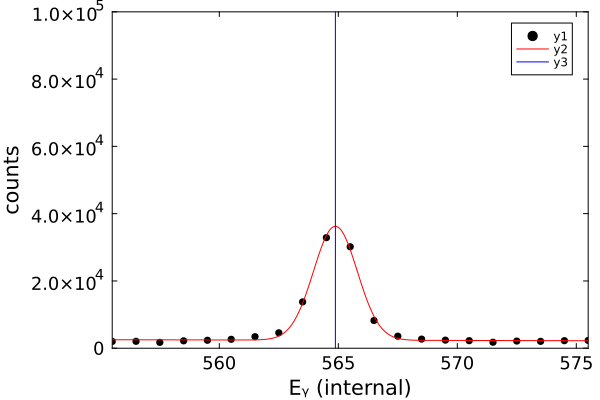

In [12]:
c0c1_p1_mean = 565.5

c0c1_x1low,c0c1_x1high=c0c1_p1_mean-10,c0c1_p1_mean+10; ylow,yhigh=0,1.0e5
c0c1_param1=[100,0.05,2e5,c0c1_p1_mean,1.0]
    # deos anything here need to be changed/adjusted (how so?)

c0c1_p1,c0c1_s1,f=PhotopeakFit.gaussianfit(kc0c1,c0c1_x1low,c0c1_x1high,c0c1_param1)

for (i,val) in enumerate(c0c1_p1)
    println("P$i = ",val,"($(c0c1_s1[i]))")
end
println("Calibrated - Expected = $(c0c1_p1[4] - kliterature[1]) keV")

scatter(kc0c1[:,1],kc0c1[:,2],xlims=(c0c1_x1low,c0c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c1_p1),c0c1_x1low,c0c1_x1high,lc=:red)
vline!([c0c1_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 111729.05980915039(16309.598796288263)
P2 = -181.81971813442536(28.82797872529627)
P3 = 443793.895429056(1767.1662850351322)
P4 = 586.171009912917(0.020597375318193934)
P5 = 0.9770225459909501(0.022174682272114894)
Calibrated - Expected = 0.16100991291705213 keV


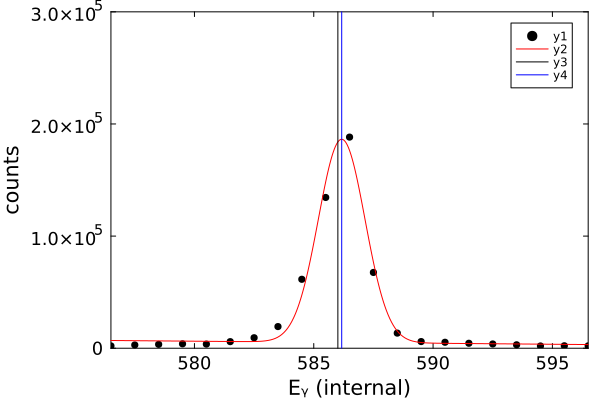

In [13]:
c0c1_p2_mean = 586.5
c0c1_x1low,c0c1_x1high=c0c1_p2_mean-10,c0c1_p2_mean+10; ylow,yhigh=0,300000
c0c1_param1=[100,0.05,2e5,c0c1_p2_mean,1.0]

c0c1_p2,c0c1_s2,f=PhotopeakFit.gaussianfit(kc0c1,c0c1_x1low,c0c1_x1high,c0c1_param1)

for (i,val) in enumerate(c0c1_p2)
    println("P$i = ",val,"($(c0c1_s1[i]))")
end
println("Calibrated - Expected = $(c0c1_p2[4] - kliterature[2]) keV")

scatter(kc0c1[:,1],kc0c1[:,2],xlims=(c0c1_x1low,c0c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c1_p2),c0c1_x1low,c0c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c1_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 135297.17762407538(16309.598796288263)
P2 = -66.4154048907348(28.82797872529627)
P3 = 189796.5623450154(1767.1662850351322)
P4 = 2012.8836494314655(0.020597375318193934)
P5 = 1.2235896710158274(0.022174682272114894)
Calibrated - Expected = -0.5663505685345172 keV


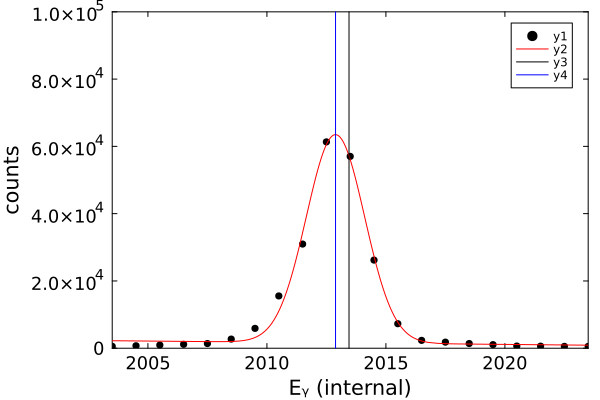

In [14]:
c0c1_p3_mean = 2013.5
c0c1_x1low,c0c1_x1high=c0c1_p3_mean-10,c0c1_p3_mean+10; ylow,yhigh=0,1e5
c0c1_param1=[100,0.05,2e5,c0c1_p3_mean,1.0]

c0c1_p3,c0c1_s3,f=PhotopeakFit.gaussianfit(kc0c1,c0c1_x1low,c0c1_x1high,c0c1_param1)

for (i,val) in enumerate(c0c1_p3)
    println("P$i = ",val,"($(c0c1_s1[i]))")
end
println("Calibrated - Expected = $(c0c1_p3[4] - kliterature[3]) keV")

scatter(kc0c1[:,1],kc0c1[:,2],xlims=(c0c1_x1low,c0c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c1_p3),c0c1_x1low,c0c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c1_p3[4]],lc=:blue)

## Crystal 2 (c0c2)

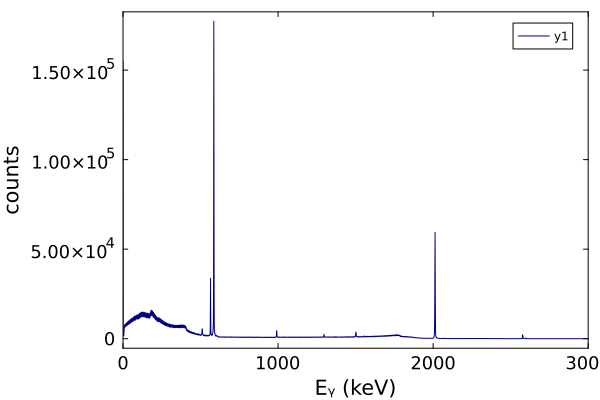

In [15]:
kc0c2 = Matrix(select(data[data.y_center .== 2.5, :], Not(:y_center)))

plot(kc0c2[:,1],kc0c2[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 12219.525925710157(10798.001579082968)
P2 = -17.65973480479797(19.082596001900722)
P3 = 67973.97531154245(1102.3991009004142)
P4 = 564.4586461341697(0.014369311860635602)
P5 = 0.8638120919345138(0.014232323313155893)
Calibrated - Expected = -0.33135386583023774 keV


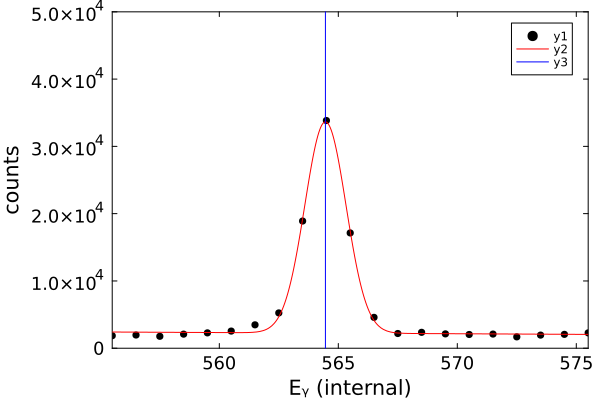

In [16]:
c0c2_p1_mean = 565.5
c0c2_x1low,c0c2_x1high=c0c2_p1_mean-10,c0c2_p1_mean+10; ylow,yhigh=0,5e4
c0c2_param1=[100,0.05,2e5,c0c2_p1_mean,1.0]

c0c2_p1,c0c2_s1,f=PhotopeakFit.gaussianfit(kc0c2,c0c2_x1low,c0c2_x1high,c0c2_param1)

for (i,val) in enumerate(c0c2_p1)
    println("P$i = ",val,"($(c0c2_s1[i]))")
end
println("Calibrated - Expected = $(c0c2_p1[4] - kliterature[1]) keV")

scatter(kc0c2[:,1],kc0c2[:,2],xlims=(c0c2_x1low,c0c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c2_p1),c0c2_x1low,c0c2_x1high,lc=:red)
vline!([c0c2_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 81105.97547763262(10798.001579082968)
P2 = -130.84136494706192(19.082596001900722)
P3 = 392961.17189708457(1102.3991009004142)
P4 = 585.6990793298773(0.014369311860635602)
P5 = 0.8871173074980044(0.014232323313155893)
Calibrated - Expected = -0.31092067012264124 keV


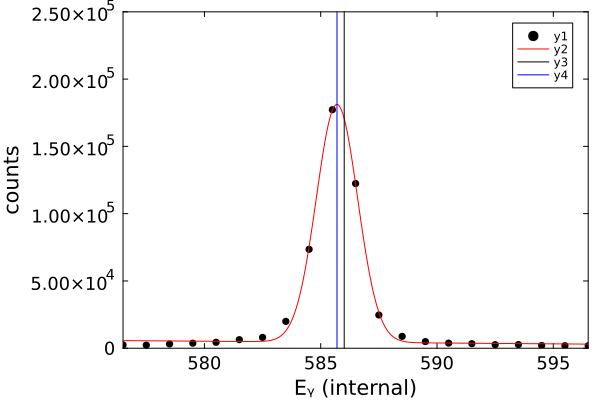

In [17]:
c0c2_p2_mean = 586.5
c0c2_x1low,c0c2_x1high=c0c2_p2_mean-10,c0c2_p2_mean+10; ylow,yhigh=0,2.5e5
c0c2_param1=[100,0.05,2e5,c0c2_p2_mean,1.0]

c0c2_p2,c0c2_s2,f=PhotopeakFit.gaussianfit(kc0c2,c0c2_x1low,c0c2_x1high,c0c2_param1)

for (i,val) in enumerate(c0c2_p2)
    println("P$i = ",val,"($(c0c2_s1[i]))")
end
println("Calibrated - Expected = $(c0c2_p2[4] - kliterature[2]) keV")

scatter(kc0c2[:,1],kc0c2[:,2],xlims=(c0c2_x1low,c0c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c2_p2),c0c2_x1low,c0c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c2_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 117349.78654204376(10798.001579082968)
P2 = -57.58339919859391(19.082596001900722)
P3 = 178144.3671447621(1102.3991009004142)
P4 = 2012.4114982103904(0.014369311860635602)
P5 = 1.2920997688989875(0.014232323313155893)
Calibrated - Expected = -1.0385017896096542 keV


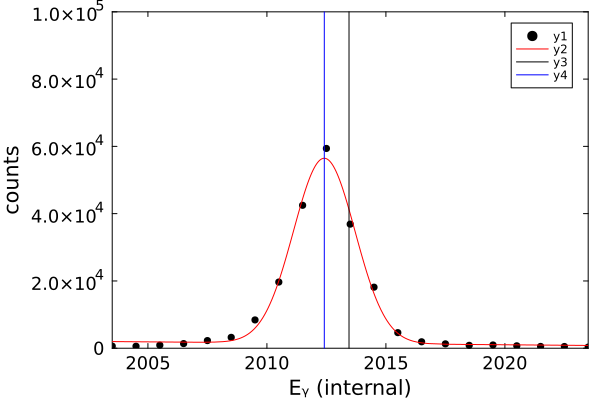

In [18]:
c0c2_p3_mean = 2013.5
c0c2_x1low,c0c2_x1high=c0c2_p3_mean-10,c0c2_p3_mean+10; ylow,yhigh=0,1e5
c0c2_param1=[100,0.05,2e5,c0c2_p3_mean,1.0]

c0c2_p3,c0c2_s3,f=PhotopeakFit.gaussianfit(kc0c2,c0c2_x1low,c0c2_x1high,c0c2_param1)

for (i,val) in enumerate(c0c2_p3)
    println("P$i = ",val,"($(c0c2_s1[i]))")
end
println("Calibrated - Expected = $(c0c2_p3[4] - kliterature[3]) keV")

scatter(kc0c2[:,1],kc0c2[:,2],xlims=(c0c2_x1low,c0c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c2_p3),c0c2_x1low,c0c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c2_p3[4]],lc=:blue)

## Crystal 3 (c0c3)

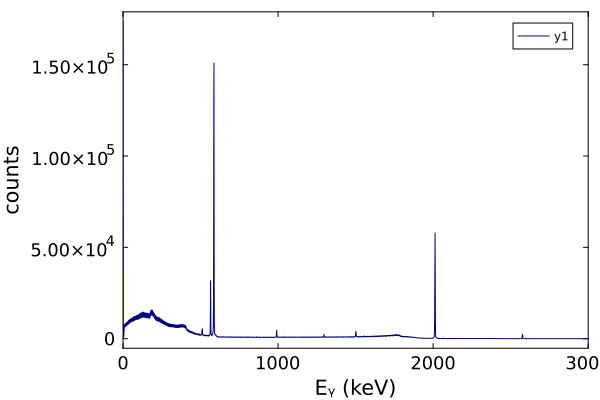

In [19]:
kc0c3 = Matrix(select(data[data.y_center .== 3.5, :], Not(:y_center)))

plot(kc0c3[:,1],kc0c3[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 12410.973973459653(9317.614112834604)
P2 = -18.236010967791657(16.467009466146234)
P3 = 71837.31329289277(1025.1977033567111)
P4 = 564.6773709522699(0.013505698903548594)
P5 = 0.9525455789976643(0.014123578392094022)
Calibrated - Expected = -0.11262904773002447 keV


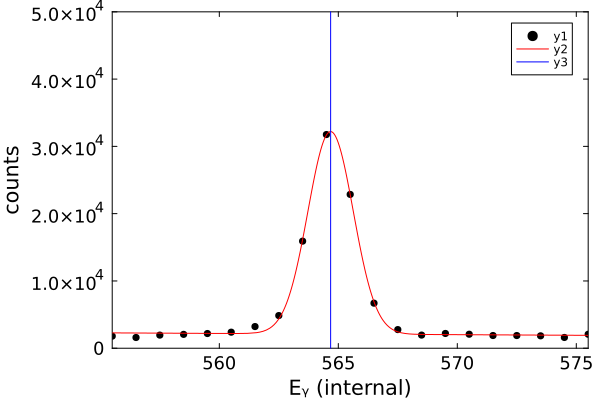

In [20]:
c0c3_p1_mean = 565.5
c0c3_x1low,c0c3_x1high=c0c3_p1_mean-10,c0c3_p1_mean+10; ylow,yhigh=0,5e4
c0c3_param1=[100,0.05,2e5,c0c3_p1_mean,1.0]

c0c3_p1,c0c3_s1,f=PhotopeakFit.gaussianfit(kc0c3,c0c3_x1low,c0c3_x1high,c0c3_param1)

for (i,val) in enumerate(c0c3_p1)
    println("P$i = ",val,"($(c0c3_s1[i]))")
end
println("Calibrated - Expected = $(c0c3_p1[4] - kliterature[1]) keV")

scatter(kc0c3[:,1],kc0c3[:,2],xlims=(c0c3_x1low,c0c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c3_p1),c0c3_x1low,c0c3_x1high,lc=:red)
vline!([c0c3_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 88470.48579139737(9317.614112834604)
P2 = -144.84385478477054(16.467009466146234)
P3 = 417734.2658429874(1025.1977033567111)
P4 = 585.9378818745415(0.013505698903548594)
P5 = 1.07768420501241(0.014123578392094022)
Calibrated - Expected = -0.07211812545847351 keV


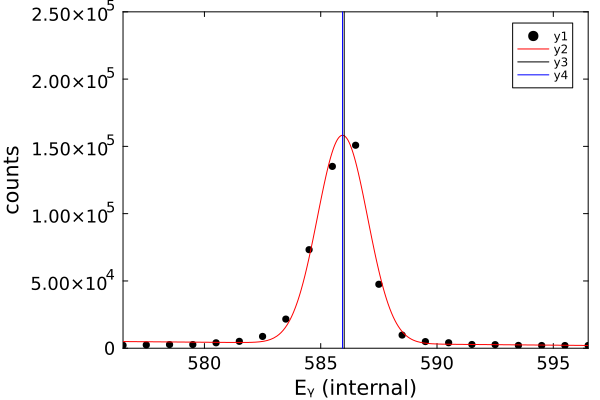

In [21]:
c0c3_p2_mean = 586.5
c0c3_x1low,c0c3_x1high=c0c3_p2_mean-10,c0c3_p2_mean+10; ylow,yhigh=0,2.5e5
c0c3_param1=[100,0.05,2e5,c0c3_p2_mean,1.0]

c0c3_p2,c0c3_s2,f=PhotopeakFit.gaussianfit(kc0c3,c0c3_x1low,c0c3_x1high,c0c3_param1)

for (i,val) in enumerate(c0c3_p2)
    println("P$i = ",val,"($(c0c3_s1[i]))")
end
println("Calibrated - Expected = $(c0c3_p2[4] - kliterature[2]) keV")

scatter(kc0c3[:,1],kc0c3[:,2],xlims=(c0c3_x1low,c0c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c3_p2),c0c3_x1low,c0c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c3_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 118621.17449278875(9317.614112834604)
P2 = -58.401089415627915(16.467009466146234)
P3 = 183838.9619251094(1025.1977033567111)
P4 = 2012.227503804575(0.013505698903548594)
P5 = 1.3584049567838827(0.014123578392094022)
Calibrated - Expected = -1.2224961954250375 keV


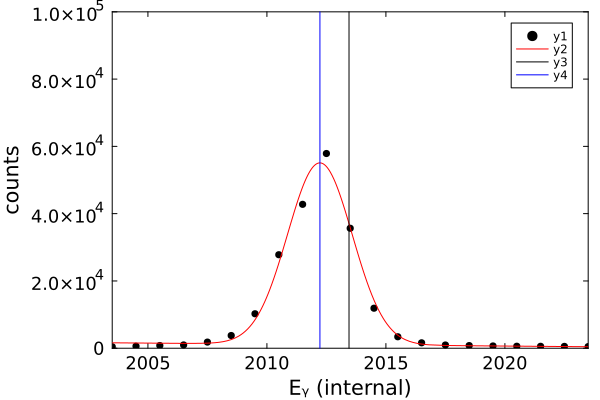

In [22]:
c0c3_p3_mean = 2013.5
c0c3_x1low,c0c3_x1high=c0c3_p3_mean-10,c0c3_p3_mean+10; ylow,yhigh=0,1e5
c0c3_param1=[100,0.05,2e5,c0c3_p3_mean,1.0]

c0c3_p3,c0c3_s3,f=PhotopeakFit.gaussianfit(kc0c3,c0c3_x1low,c0c3_x1high,c0c3_param1)

for (i,val) in enumerate(c0c3_p3)
    println("P$i = ",val,"($(c0c3_s1[i]))")
end
println("Calibrated - Expected = $(c0c3_p3[4] - kliterature[3]) keV")

scatter(kc0c3[:,1],kc0c3[:,2],xlims=(c0c3_x1low,c0c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c0c3_p3),c0c3_x1low,c0c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c0c3_p3[4]],lc=:blue)

## Clover 0 Areas

In [23]:
c0_areas = [(c0c0_p1[3] + c0c1_p1[3] + c0c2_p1[3] + c0c3_p1[3]), 
            (c0c0_p2[3] + c0c1_p2[3] + c0c2_p2[3] + c0c3_p2[3]), 
            (c0c0_p3[3] + c0c1_p3[3] + c0c2_p3[3] + c0c3_p3[3])]

c0_σareas = [(c0c0_s1[3]^2 + c0c1_s1[3]^2 + c0c2_s1[3]^2 + c0c3_s1[3]^2)^(1/2),
             (c0c0_s2[3]^2 + c0c1_s2[3]^2 + c0c2_s2[3]^2 + c0c3_s2[3]^2)^(1/2),
             (c0c0_s3[3]^2 + c0c1_s3[3]^2 + c0c2_s3[3]^2 + c0c3_s3[3]^2)^(1/2)]

3-element Vector{Float64}:
  3132.2592055070113
 29100.814308465426
 13286.440030433787

# Clover 1

## Crystal 4 (c1c0)

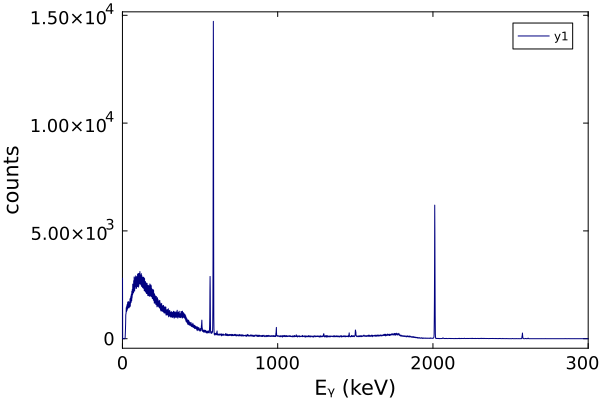

In [24]:
kc1c0 = Matrix(select(data[data.y_center .== 4.5, :], Not(:y_center)))

plot(kc1c0[:,1],kc1c0[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 2507.0226744248666(1352.2462135936257)
P2 = -3.92406071795949(2.3888400003574723)
P3 = 8112.639570049575(178.48879793181152)
P4 = 564.4972085754122(0.025449293049939013)
P5 = 1.2345590956989767(0.027371750349734207)
Calibrated - Expected = -0.29279142458779006 keV


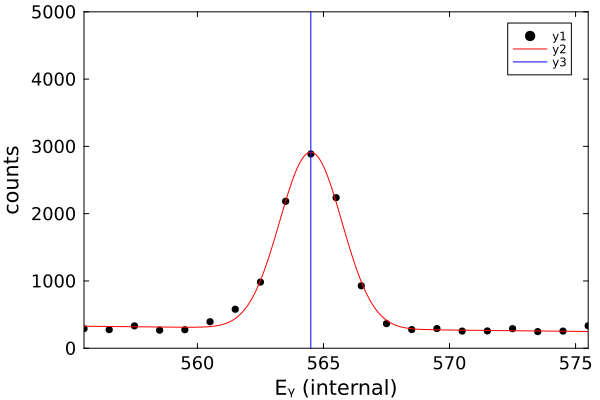

In [25]:
c1c0_p1_mean = 565.5
c1c0_x1low,c1c0_x1high=c1c0_p1_mean-10,c1c0_p1_mean+10; ylow,yhigh=0,5e3
c1c0_param1=[100,0.05,2e5,c1c0_p1_mean,1.0]

c1c0_p1,c1c0_s1,f=PhotopeakFit.gaussianfit(kc1c0,c1c0_x1low,c1c0_x1high,c1c0_param1)

for (i,val) in enumerate(c1c0_p1)
    println("P$i = ",val,"($(c1c0_s1[i]))")
end
println("Calibrated - Expected = $(c1c0_p1[4] - kliterature[1]) keV")

scatter(kc1c0[:,1],kc1c0[:,2],xlims=(c1c0_x1low,c1c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c0_p1),c1c0_x1low,c1c0_x1high,lc=:red)
vline!([c1c0_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 9754.419021061878(1352.2462135936257)
P2 = -16.096836483343004(2.3888400003574723)
P3 = 46048.13595198661(178.48879793181152)
P4 = 585.6696340707745(0.025449293049939013)
P5 = 1.2506586524942631(0.027371750349734207)
Calibrated - Expected = -0.340365929225527 keV


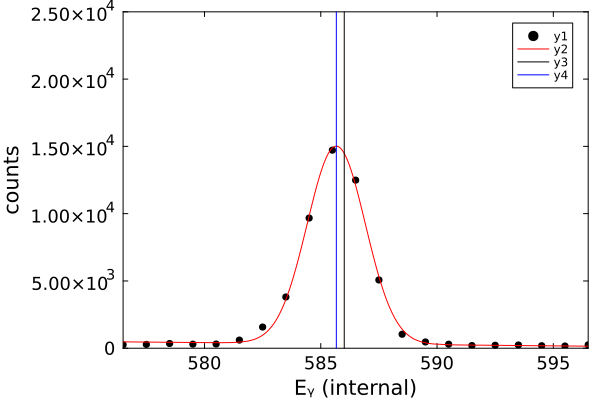

In [26]:
c1c0_p2_mean = 586.5
c1c0_x1low,c1c0_x1high=c1c0_p2_mean-10,c1c0_p2_mean+10; ylow,yhigh=0,2.5e4
c1c0_param1=[100,0.05,2e5,c1c0_p2_mean,1.0]

c1c0_p2,c1c0_s2,f=PhotopeakFit.gaussianfit(kc1c0,c1c0_x1low,c1c0_x1high,c1c0_param1)

for (i,val) in enumerate(c1c0_p2)
    println("P$i = ",val,"($(c1c0_s1[i]))")
end
println("Calibrated - Expected = $(c1c0_p2[4] - kliterature[2]) keV")

scatter(kc1c0[:,1],kc1c0[:,2],xlims=(c1c0_x1low,c1c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c0_p2),c1c0_x1low,c1c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c0_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 15926.904301616676(1352.2462135936257)
P2 = -7.867462083092008(2.3888400003574723)
P3 = 20112.381604394628(178.48879793181152)
P4 = 2011.7673087235837(0.025449293049939013)
P5 = 1.399489707125437(0.027371750349734207)
Calibrated - Expected = -1.6826912764163353 keV


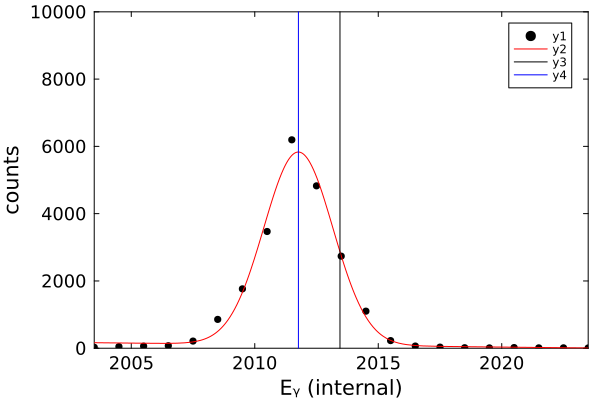

In [27]:
c1c0_p3_mean = 2013.5
c1c0_x1low,c1c0_x1high=c1c0_p3_mean-10,c1c0_p3_mean+10; ylow,yhigh=0,1e4
c1c0_param1=[100,0.05,2e5,c1c0_p3_mean,1.0]

c1c0_p3,c1c0_s3,f=PhotopeakFit.gaussianfit(kc1c0,c1c0_x1low,c1c0_x1high,c1c0_param1)

for (i,val) in enumerate(c1c0_p3)
    println("P$i = ",val,"($(c1c0_s1[i]))")
end
println("Calibrated - Expected = $(c1c0_p3[4] - kliterature[3]) keV")

scatter(kc1c0[:,1],kc1c0[:,2],xlims=(c1c0_x1low,c1c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c0_p3),c1c0_x1low,c1c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c0_p3[4]],lc=:blue)

## Crystal 5 (c1c1)

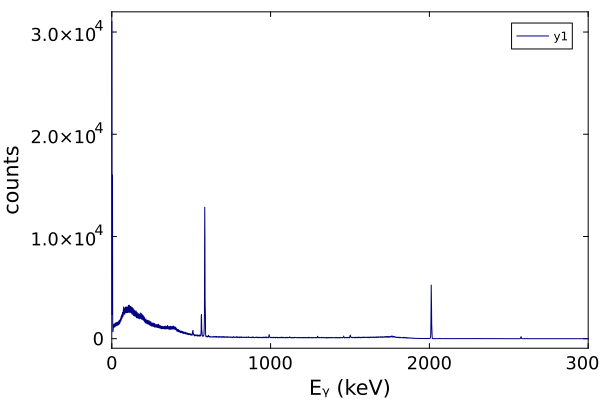

In [28]:
kc1c1 = Matrix(select(data[data.y_center .== 5.5, :], Not(:y_center)))

plot(kc1c1[:,1],kc1c1[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 959.087311064245(3566.48139118756)
P2 = -1.1230485383647595(6.299945980777895)
P3 = 6932.936110293939(485.2819274757931)
P4 = 564.4809710891625(0.08349847925811027)
P5 = 1.286814873297135(0.0901529269444087)
Calibrated - Expected = -0.3090289108374691 keV


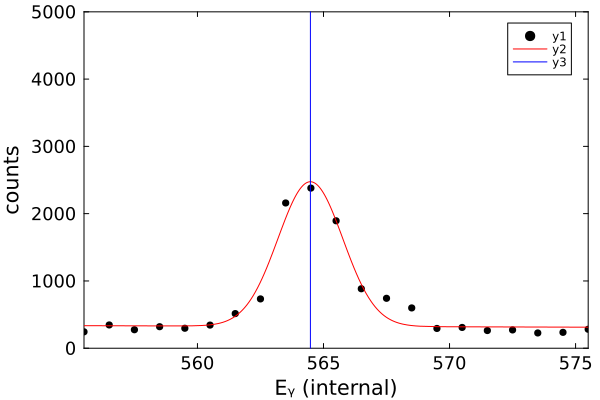

In [29]:
c1c1_p1_mean = 565.5
c1c1_x1low,c1c1_x1high=c1c1_p1_mean-10,c1c1_p1_mean+10; ylow,yhigh=0,5e3
c1c1_param1=[100,0.05,2e5,c1c1_p1_mean,1.0]

c1c1_p1,c1c1_s1,f=PhotopeakFit.gaussianfit(kc1c1,c1c1_x1low,c1c1_x1high,c1c1_param1)

for (i,val) in enumerate(c1c1_p1)
    println("P$i = ",val,"($(c1c1_s1[i]))")
end
println("Calibrated - Expected = $(c1c1_p1[4] - kliterature[1]) keV")

scatter(kc1c1[:,1],kc1c1[:,2],xlims=(c1c1_x1low,c1c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c1_p1),c1c1_x1low,c1c1_x1high,lc=:red)
vline!([c1c1_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = -2459.225797750982(3566.48139118756)
P2 = 5.1699130531307(6.299945980777895)
P3 = 38712.36404974249(485.2819274757931)
P4 = 585.599490529502(0.08349847925811027)
P5 = 1.2485363805609193(0.0901529269444087)
Calibrated - Expected = -0.41050947049802744 keV


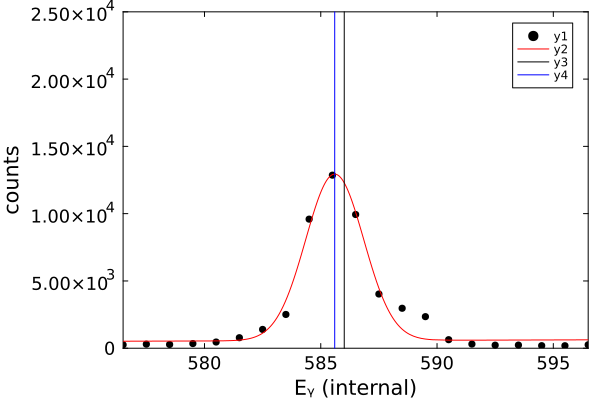

In [30]:
c1c1_p2_mean = 586.5
c1c1_x1low,c1c1_x1high=c1c1_p2_mean-10,c1c1_p2_mean+10; ylow,yhigh=0,2.5e4
c1c1_param1=[100,0.05,2e5,c1c1_p2_mean,1.0]

c1c1_p2,c1c1_s2,f=PhotopeakFit.gaussianfit(kc1c1,c1c1_x1low,c1c1_x1high,c1c1_param1)

for (i,val) in enumerate(c1c1_p2)
    println("P$i = ",val,"($(c1c1_s1[i]))")
end
println("Calibrated - Expected = $(c1c1_p2[4] - kliterature[2]) keV")

scatter(kc1c1[:,1],kc1c1[:,2],xlims=(c1c1_x1low,c1c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c1_p2),c1c1_x1low,c1c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c1_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = -493.08682614559723(3566.48139118756)
P2 = 0.3038421485224418(6.299945980777895)
P3 = 18773.715777699825(485.2819274757931)
P4 = 2012.009500047953(0.08349847925811027)
P5 = 1.5958490306004929(0.0901529269444087)
Calibrated - Expected = -1.4404999520470483 keV


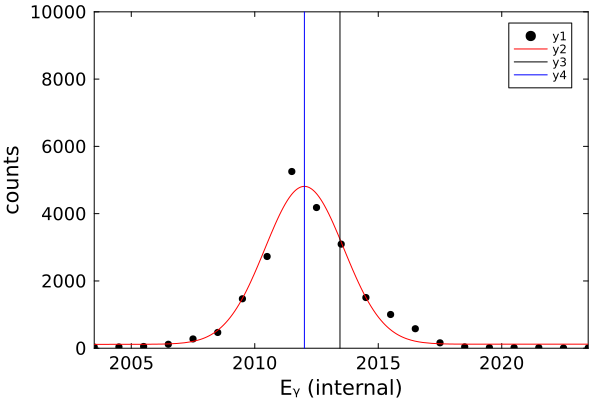

In [31]:
c1c1_p3_mean = 2013.5
c1c1_x1low,c1c1_x1high=c1c1_p3_mean-10,c1c1_p3_mean+10; ylow,yhigh=0,1e4
c1c1_param1=[100,0.05,2e5,c1c1_p3_mean,1.0]

c1c1_p3,c1c1_s3,f=PhotopeakFit.gaussianfit(kc1c1,c1c1_x1low,c1c1_x1high,c1c1_param1)

for (i,val) in enumerate(c1c1_p3)
    println("P$i = ",val,"($(c1c1_s1[i]))")
end
println("Calibrated - Expected = $(c1c1_p3[4] - kliterature[3]) keV")

scatter(kc1c1[:,1],kc1c1[:,2],xlims=(c1c1_x1low,c1c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c1_p3),c1c1_x1low,c1c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c1_p3[4]],lc=:blue)

## Crystal 6 (c1c2)

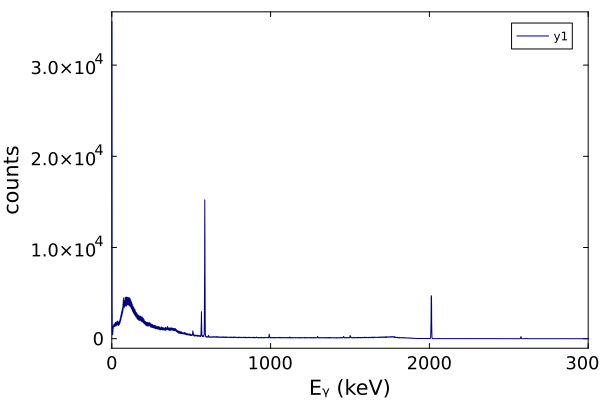

In [32]:
kc1c2 = Matrix(select(data[data.y_center .== 6.5, :], Not(:y_center)))

plot(kc1c2[:,1],kc1c2[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 1802.6879071644496(3026.1182694994723)
P2 = -2.6703122755820914(5.3464096369303915)
P3 = 7254.100008847951(386.3624159954344)
P4 = 564.5426211390403(0.059521919657372725)
P5 = 1.178909592825535(0.06373762936089813)
Calibrated - Expected = -0.24737886095965678 keV


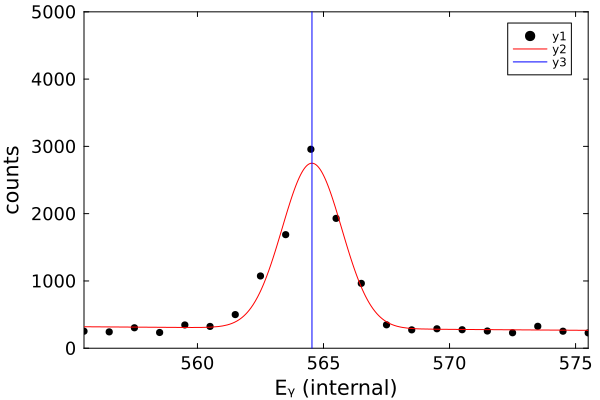

In [33]:
c1c2_p1_mean = 565.5
c1c2_x1low,c1c2_x1high=c1c2_p1_mean-10,c1c2_p1_mean+10; ylow,yhigh=0,5e3
c1c2_param1=[100,0.05,2e5,c1c2_p1_mean,1.0]

c1c2_p1,c1c2_s1,f=PhotopeakFit.gaussianfit(kc1c2,c1c2_x1low,c1c2_x1high,c1c2_param1)

for (i,val) in enumerate(c1c2_p1)
    println("P$i = ",val,"($(c1c2_s1[i]))")
end
println("Calibrated - Expected = $(c1c2_p1[4] - kliterature[1]) keV")

scatter(kc1c2[:,1],kc1c2[:,2],xlims=(c1c2_x1low,c1c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c2_p1),c1c2_x1low,c1c2_x1high,lc=:red)
vline!([c1c2_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 9294.877105689384(3026.1182694994723)
P2 = -15.220714152363204(5.3464096369303915)
P3 = 42180.36314875268(386.3624159954344)
P4 = 585.7175697297619(0.059521919657372725)
P5 = 1.1944317661295758(0.06373762936089813)
Calibrated - Expected = -0.2924302702381283 keV


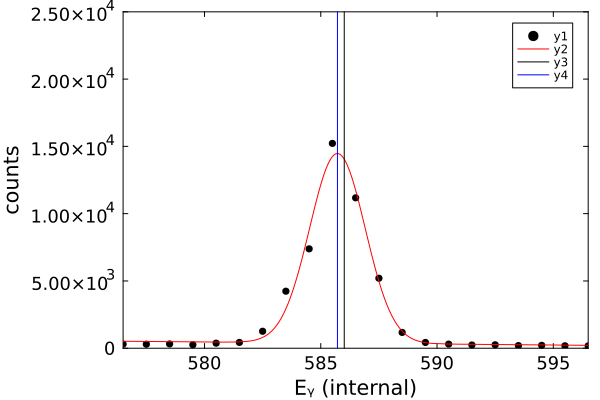

In [34]:
c1c2_p2_mean = 586.5
c1c2_x1low,c1c2_x1high=c1c2_p2_mean-10,c1c2_p2_mean+10; ylow,yhigh=0,2.5e4
c1c2_param1=[100,0.05,2e5,c1c2_p2_mean,1.0]

c1c2_p2,c1c2_s2,f=PhotopeakFit.gaussianfit(kc1c2,c1c2_x1low,c1c2_x1high,c1c2_param1)

for (i,val) in enumerate(c1c2_p2)
    println("P$i = ",val,"($(c1c2_s1[i]))")
end
println("Calibrated - Expected = $(c1c2_p2[4] - kliterature[2]) keV")

scatter(kc1c2[:,1],kc1c2[:,2],xlims=(c1c2_x1low,c1c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c2_p2),c1c2_x1low,c1c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c2_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 11425.769821190892(3026.1182694994723)
P2 = -5.651981057648979(5.3464096369303915)
P3 = 19605.386945527865(386.3624159954344)
P4 = 2012.392377232242(0.059521919657372725)
P5 = 1.5250473375197098(0.06373762936089813)
Calibrated - Expected = -1.0576227677579482 keV


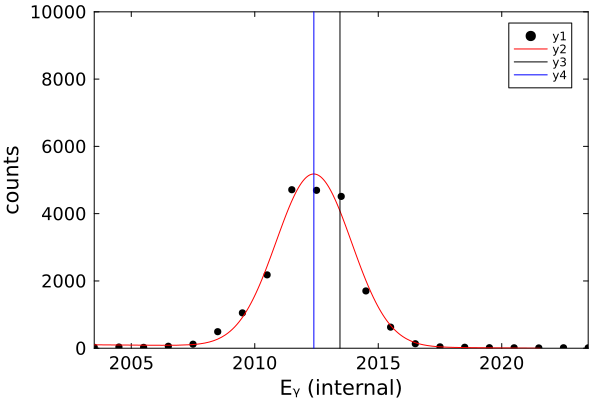

In [35]:
c1c2_p3_mean = 2013.5
c1c2_x1low,c1c2_x1high=c1c2_p3_mean-10,c1c2_p3_mean+10; ylow,yhigh=0,1e4
c1c2_param1=[100,0.05,2e5,c1c2_p3_mean,1.0]

c1c2_p3,c1c2_s3,f=PhotopeakFit.gaussianfit(kc1c2,c1c2_x1low,c1c2_x1high,c1c2_param1)

for (i,val) in enumerate(c1c2_p3)
    println("P$i = ",val,"($(c1c2_s1[i]))")
end
println("Calibrated - Expected = $(c1c2_p3[4] - kliterature[3]) keV")

scatter(kc1c2[:,1],kc1c2[:,2],xlims=(c1c2_x1low,c1c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c2_p3),c1c2_x1low,c1c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c2_p3[4]],lc=:blue)

## Crystal 7 (c1c3)

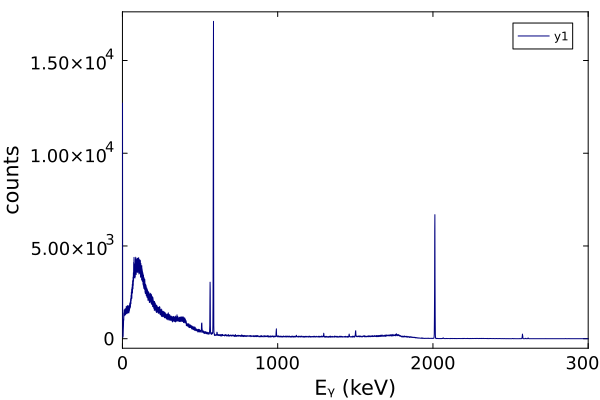

In [36]:
kc1c3 = Matrix(select(data[data.y_center .== 7.5, :], Not(:y_center)))

plot(kc1c3[:,1],kc1c3[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = 1713.8005624240682(2573.2970894211985)
P2 = -2.523249316927507(4.547188455229707)
P3 = 7910.841598384879(307.89108780366024)
P4 = 564.6342579937414(0.040533657600966014)
P5 = 1.0753336859298166(0.04301995879301696)
Calibrated - Expected = -0.15574200625860612 keV


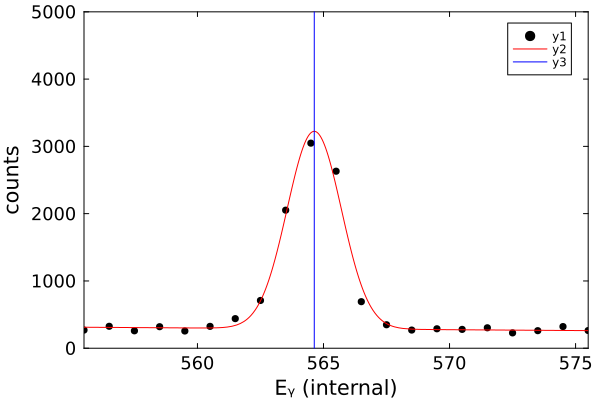

In [37]:
c1c3_p1_mean = 565.5
c1c3_x1low,c1c3_x1high=c1c3_p1_mean-10,c1c3_p1_mean+10; ylow,yhigh=0,5e3
c1c3_param1=[100,0.05,2e5,c1c3_p1_mean,1.0]

c1c3_p1,c1c3_s1,f=PhotopeakFit.gaussianfit(kc1c3,c1c3_x1low,c1c3_x1high,c1c3_param1)

for (i,val) in enumerate(c1c3_p1)
    println("P$i = ",val,"($(c1c3_s1[i]))")
end
println("Calibrated - Expected = $(c1c3_p1[4] - kliterature[1]) keV")

scatter(kc1c3[:,1],kc1c3[:,2],xlims=(c1c3_x1low,c1c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c3_p1),c1c3_x1low,c1c3_x1high,lc=:red)
vline!([c1c3_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 9495.354287343289(2573.2970894211985)
P2 = -15.704808836849375(4.547188455229707)
P3 = 46397.80583643025(307.89108780366024)
P4 = 585.9445155656508(0.040533657600966014)
P5 = 1.0575638140383732(0.04301995879301696)
Calibrated - Expected = -0.06548443434917317 keV


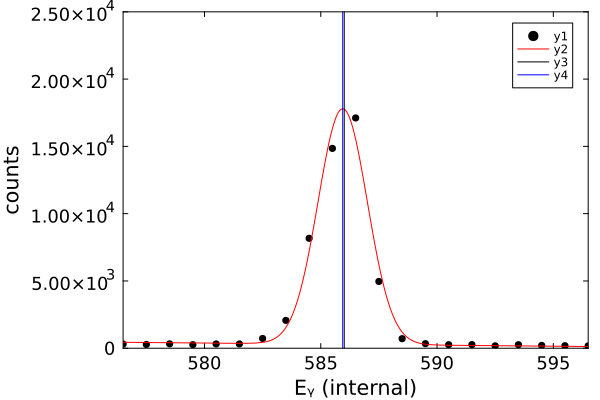

In [38]:
c1c3_p2_mean = 586.5
c1c3_x1low,c1c3_x1high=c1c3_p2_mean-10,c1c3_p2_mean+10; ylow,yhigh=0,2.5e4
c1c3_param1=[100,0.05,2e5,c1c3_p2_mean,1.0]

c1c3_p2,c1c3_s2,f=PhotopeakFit.gaussianfit(kc1c3,c1c3_x1low,c1c3_x1high,c1c3_param1)

for (i,val) in enumerate(c1c3_p2)
    println("P$i = ",val,"($(c1c3_s1[i]))")
end
println("Calibrated - Expected = $(c1c3_p2[4] - kliterature[2]) keV")

scatter(kc1c3[:,1],kc1c3[:,2],xlims=(c1c3_x1low,c1c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c3_p2),c1c3_x1low,c1c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c3_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 10807.017748401522(2573.2970894211985)
P2 = -5.328694309861906(4.547188455229707)
P3 = 20227.85664567316(307.89108780366024)
P4 = 2012.1354637215406(0.040533657600966014)
P5 = 1.2120217145816485(0.04301995879301696)
Calibrated - Expected = -1.3145362784594 keV


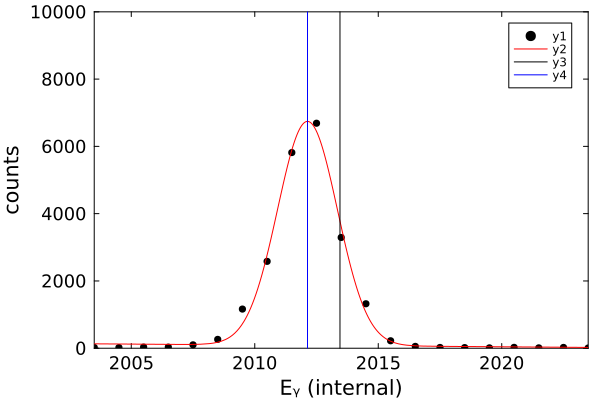

In [39]:
c1c3_p3_mean = 2013.5
c1c3_x1low,c1c3_x1high=c1c3_p3_mean-10,c1c3_p3_mean+10; ylow,yhigh=0,1e4
c1c3_param1=[100,0.05,2e5,c1c3_p3_mean,1.0]

c1c3_p3,c1c3_s3,f=PhotopeakFit.gaussianfit(kc1c3,c1c3_x1low,c1c3_x1high,c1c3_param1)

for (i,val) in enumerate(c1c3_p3)
    println("P$i = ",val,"($(c1c3_s1[i]))")
end
println("Calibrated - Expected = $(c1c3_p3[4] - kliterature[3]) keV")

scatter(kc1c3[:,1],kc1c3[:,2],xlims=(c1c3_x1low,c1c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c1c3_p3),c1c3_x1low,c1c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c1c3_p3[4]],lc=:blue)

## Clover 1 Areas

In [40]:
c1_areas = [(c1c0_p1[3] + c1c1_p1[3] + c1c2_p1[3] + c1c3_p1[3]), 
            (c1c0_p2[3] + c1c1_p2[3] + c1c2_p2[3] + c1c3_p2[3]), 
            (c1c0_p3[3] + c1c1_p3[3] + c1c2_p3[3] + c1c3_p3[3])]

c1_σareas = [(c1c0_s1[3]^2 + c1c1_s1[3]^2 + c1c2_s1[3]^2 + c1c3_s1[3]^2)^(1/2),
             (c1c0_s2[3]^2 + c1c1_s2[3]^2 + c1c2_s2[3]^2 + c1c3_s2[3]^2)^(1/2),
             (c1c0_s3[3]^2 + c1c1_s3[3]^2 + c1c2_s3[3]^2 + c1c3_s3[3]^2)^(1/2)]

3-element Vector{Float64}:
  715.1430895733484
 3834.4542522534252
 1813.6105833779966

# Clover 2

## Crystal 8 (c2c0)

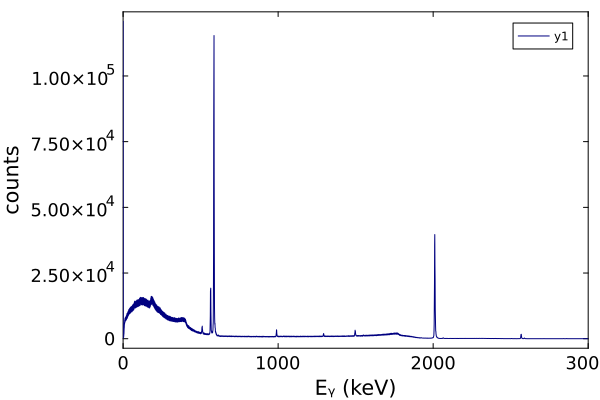

In [41]:
kc2c0 = Matrix(select(data[data.y_center .== 8.5, :], Not(:y_center)))

plot(kc2c0[:,1],kc2c0[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = -21143.20252027385(22145.294416835623)
P2 = 41.377018796060376(39.10741464309963)
P3 = 72868.47113522887(3569.383918256493)
P4 = 564.6067341368299(0.06827190164757241)
P5 = 1.5995559278640963(0.07532722667171182)
Calibrated - Expected = -0.18326586317004967 keV


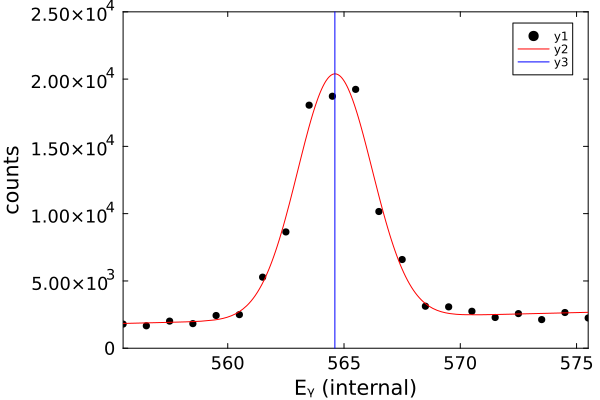

In [42]:
c2c0_p1_mean = 565.5
c2c0_x1low,c2c0_x1high=c2c0_p1_mean-10,c2c0_p1_mean+10; ylow,yhigh=0,2.5e4
c2c0_param1=[100,0.05,2e5,c2c0_p1_mean,1.0]

c2c0_p1,c2c0_s1,f=PhotopeakFit.gaussianfit(kc2c0,c2c0_x1low,c2c0_x1high,c2c0_param1)

for (i,val) in enumerate(c2c0_p1)
    println("P$i = ",val,"($(c2c0_s1[i]))")
end
println("Calibrated - Expected = $(c2c0_p1[4] - kliterature[1]) keV")

scatter(kc2c0[:,1],kc2c0[:,2],xlims=(c2c0_x1low,c2c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c0_p1),c2c0_x1low,c2c0_x1high,lc=:red)
vline!([c2c0_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = -31138.94350315764(22145.294416835623)
P2 = 60.47000372658999(39.10741464309963)
P3 = 420425.4410686374(3569.383918256493)
P4 = 585.9296731626363(0.06827190164757241)
P5 = 1.5507056213675918(0.07532722667171182)
Calibrated - Expected = -0.08032683736371382 keV


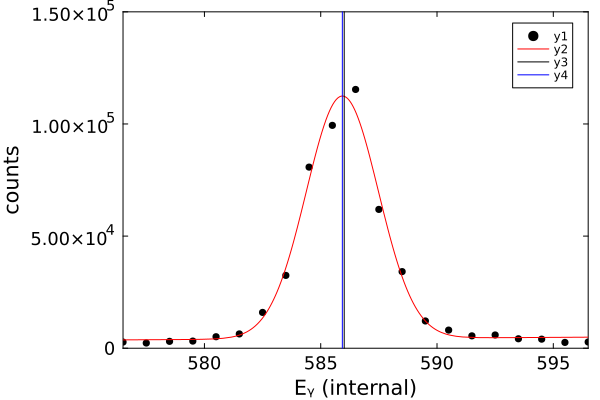

In [43]:
c2c0_p2_mean = 586.5
c2c0_x1low,c2c0_x1high=c2c0_p2_mean-10,c2c0_p2_mean+10; ylow,yhigh=0,1.5e5
c2c0_param1=[100,0.05,2e5,c2c0_p2_mean,1.0]

c2c0_p2,c2c0_s2,f=PhotopeakFit.gaussianfit(kc2c0,c2c0_x1low,c2c0_x1high,c2c0_param1)

for (i,val) in enumerate(c2c0_p2)
    println("P$i = ",val,"($(c2c0_s1[i]))")
end
println("Calibrated - Expected = $(c2c0_p2[4] - kliterature[2]) keV")

scatter(kc2c0[:,1],kc2c0[:,2],xlims=(c2c0_x1low,c2c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c0_p2),c2c0_x1low,c2c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c0_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = -118586.1036304695(22145.294416835623)
P2 = 59.658062110685506(39.10741464309963)
P3 = 176004.7777523388(3569.383918256493)
P4 = 2010.3939580687538(0.06827190164757241)
P5 = 1.9521556400132247(0.07532722667171182)
Calibrated - Expected = -3.0560419312462273 keV


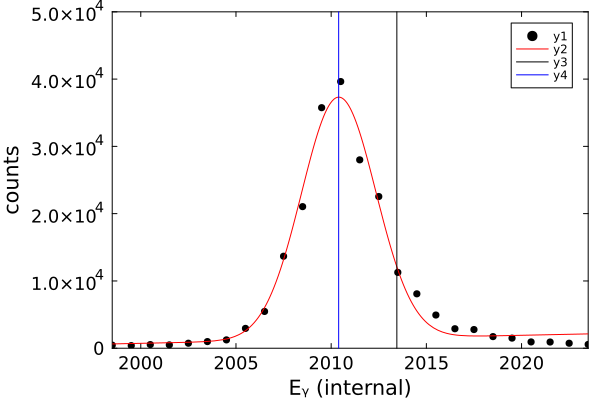

In [44]:
c2c0_p3_mean = 2013.5
c2c0_x1low,c2c0_x1high=c2c0_p3_mean-15,c2c0_p3_mean+10; ylow,yhigh=0,5e4
c2c0_param1=[100,0.05,2e5,c2c0_p3_mean,1.0]

c2c0_p3,c2c0_s3,f=PhotopeakFit.gaussianfit(kc2c0,c2c0_x1low,c2c0_x1high,c2c0_param1)

for (i,val) in enumerate(c2c0_p3)
    println("P$i = ",val,"($(c2c0_s1[i]))")
end
println("Calibrated - Expected = $(c2c0_p3[4] - kliterature[3]) keV")

scatter(kc2c0[:,1],kc2c0[:,2],xlims=(c2c0_x1low,c2c0_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c0_p3),c2c0_x1low,c2c0_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c0_p3[4]],lc=:blue)

## Crystal 9 (c2c1)

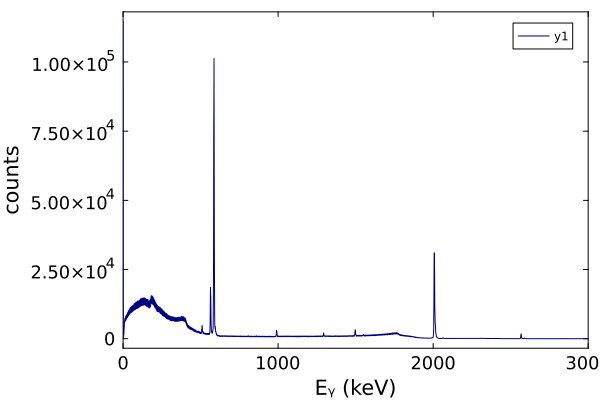

In [45]:
kc2c1 = Matrix(select(data[data.y_center .== 9.5, :], Not(:y_center)))

plot(kc2c1[:,1],kc2c1[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = -32754.03655506761(22943.320416944218)
P2 = 61.70738674222705(40.47628541482178)
P3 = 72936.82769367154(4114.542185743114)
P4 = 564.251032624782(0.08382277450515474)
P5 = 1.8135836630457947(0.09470269147672751)
Calibrated - Expected = -0.5389673752179078 keV


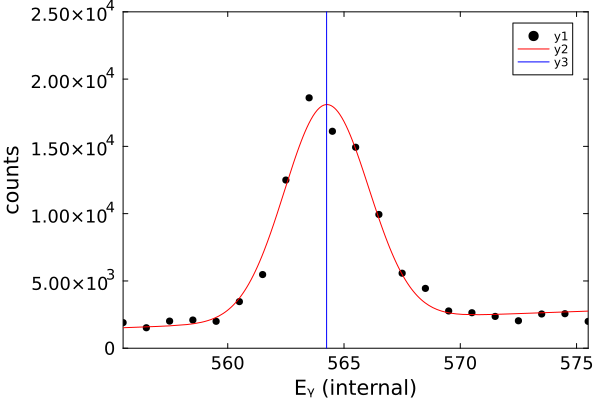

In [46]:
c2c1_p1_mean = 565.5
c2c1_x1low,c2c1_x1high=c2c1_p1_mean-10,c2c1_p1_mean+10; ylow,yhigh=0,2.5e4
c2c1_param1=[100,0.05,2e5,c2c1_p1_mean,1.0]

c2c1_p1,c2c1_s1,f=PhotopeakFit.gaussianfit(kc2c1,c2c1_x1low,c2c1_x1high,c2c1_param1)

for (i,val) in enumerate(c2c1_p1)
    println("P$i = ",val,"($(c2c1_s1[i]))")
end
println("Calibrated - Expected = $(c2c1_p1[4] - kliterature[1]) keV")

scatter(kc2c1[:,1],kc2c1[:,2],xlims=(c2c1_x1low,c2c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c1_p1),c2c1_x1low,c2c1_x1high,lc=:red)
vline!([c2c1_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = -47200.61560271336(22943.320416944218)
P2 = 86.64821401813133(40.47628541482178)
P3 = 423310.384190295(4114.542185743114)
P4 = 586.0870878374694(0.08382277450515474)
P5 = 1.7880870411328418(0.09470269147672751)
Calibrated - Expected = 0.07708783746943482 keV


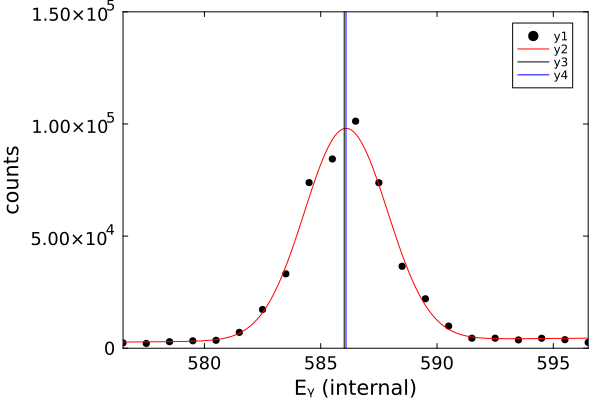

In [47]:
c2c1_p2_mean = 586.5
c2c1_x1low,c2c1_x1high=c2c1_p2_mean-10,c2c1_p2_mean+10; ylow,yhigh=0,1.5e5
c2c1_param1=[100,0.05,2e5,c2c1_p2_mean,1.0]

c2c1_p2,c2c1_s2,f=PhotopeakFit.gaussianfit(kc2c1,c2c1_x1low,c2c1_x1high,c2c1_param1)

for (i,val) in enumerate(c2c1_p2)
    println("P$i = ",val,"($(c2c1_s1[i]))")
end
println("Calibrated - Expected = $(c2c1_p2[4] - kliterature[2]) keV")

scatter(kc2c1[:,1],kc2c1[:,2],xlims=(c2c1_x1low,c2c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c1_p2),c2c1_x1low,c2c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c1_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = -156401.9777112402(22943.320416944218)
P2 = 78.60664383043635(40.47628541482178)
P3 = 164657.47376962248(4114.542185743114)
P4 = 2007.5897012823043(0.08382277450515474)
P5 = -2.1430311736460834(0.09470269147672751)
Calibrated - Expected = -5.860298717695741 keV


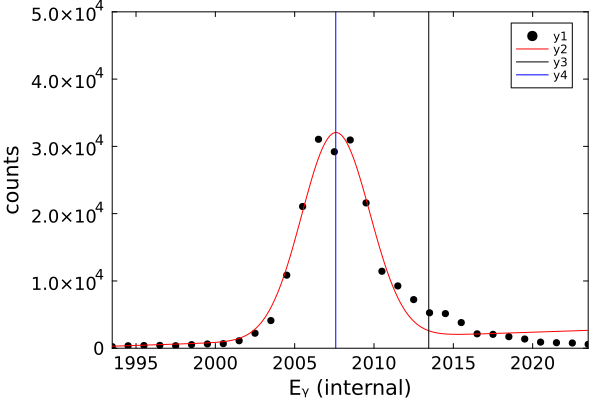

In [48]:
c2c1_p3_mean = 2013.5
c2c1_x1low,c2c1_x1high=c2c1_p3_mean-20,c2c1_p3_mean+10; ylow,yhigh=0,5e4
c2c1_param1=[100,0.05,2e5,c2c1_p3_mean,1.0]

c2c1_p3,c2c1_s3,f=PhotopeakFit.gaussianfit(kc2c1,c2c1_x1low,c2c1_x1high,c2c1_param1)

for (i,val) in enumerate(c2c1_p3)
    println("P$i = ",val,"($(c2c1_s1[i]))")
end
println("Calibrated - Expected = $(c2c1_p3[4] - kliterature[3]) keV")

scatter(kc2c1[:,1],kc2c1[:,2],xlims=(c2c1_x1low,c2c1_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c1_p3),c2c1_x1low,c2c1_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c1_p3[4]],lc=:blue)

## Crystal 10 (c2c2)

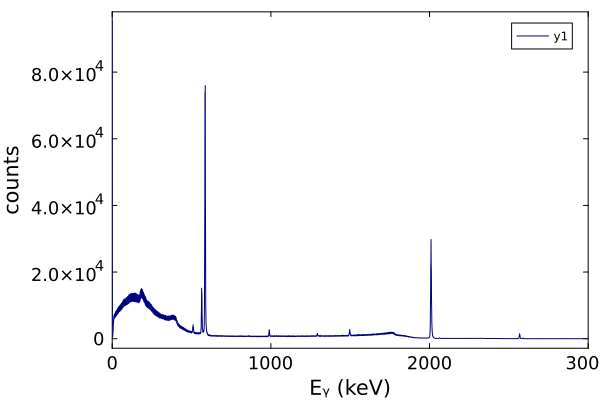

In [49]:
kc2c2 = Matrix(select(data[data.y_center .== 10.5, :], Not(:y_center)))

plot(kc2c2[:,1],kc2c2[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = -10454.690168223358(19105.07598496221)
P2 = 22.03822189248334(33.7038398992962)
P3 = 60805.62976575325(3503.1363907453097)
P4 = 564.2968266487231(0.0869330910408802)
P5 = 1.8588089087661879(0.0985389395349454)
Calibrated - Expected = -0.49317335127682327 keV


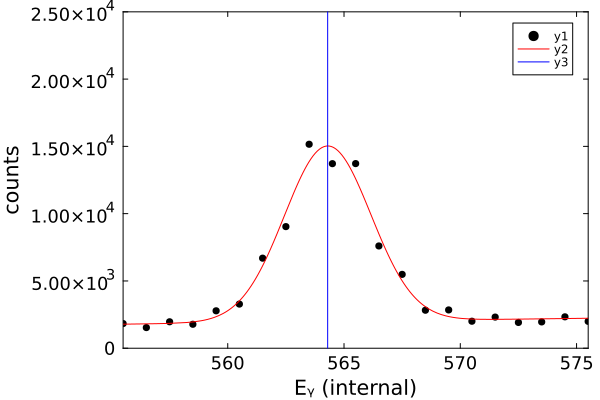

In [50]:
c2c2_p1_mean = 565.5
c2c2_x1low,c2c2_x1high=c2c2_p1_mean-10,c2c2_p1_mean+10; ylow,yhigh=0,2.5e4
c2c2_param1=[100,0.05,2e5,c2c2_p1_mean,1.0]

c2c2_p1,c2c2_s1,f=PhotopeakFit.gaussianfit(kc2c2,c2c2_x1low,c2c2_x1high,c2c2_param1)

for (i,val) in enumerate(c2c2_p1)
    println("P$i = ",val,"($(c2c2_s1[i]))")
end
println("Calibrated - Expected = $(c2c2_p1[4] - kliterature[1]) keV")

scatter(kc2c2[:,1],kc2c2[:,2],xlims=(c2c2_x1low,c2c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c2_p1),c2c2_x1low,c2c2_x1high,lc=:red)
vline!([c2c2_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = -808.8780708494322(19105.07598496221)
P2 = 6.904480724794006(33.7038398992962)
P3 = 350387.08079918165(3503.1363907453097)
P4 = 585.5327402010955(0.0869330910408802)
P5 = 1.8408070571513269(0.0985389395349454)
Calibrated - Expected = -0.4772597989044698 keV


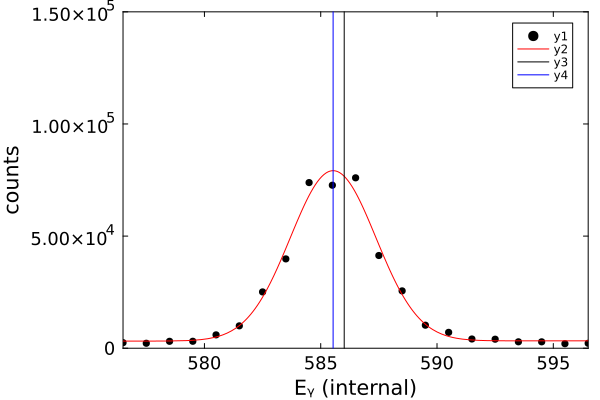

In [51]:
c2c2_p2_mean = 586.5
c2c2_x1low,c2c2_x1high=c2c2_p2_mean-10,c2c2_p2_mean+10; ylow,yhigh=0,1.5e5
c2c2_param1=[100,0.05,2e5,c2c2_p2_mean,1.0]

c2c2_p2,c2c2_s2,f=PhotopeakFit.gaussianfit(kc2c2,c2c2_x1low,c2c2_x1high,c2c2_param1)

for (i,val) in enumerate(c2c2_p2)
    println("P$i = ",val,"($(c2c2_s1[i]))")
end
println("Calibrated - Expected = $(c2c2_p2[4] - kliterature[2]) keV")

scatter(kc2c2[:,1],kc2c2[:,2],xlims=(c2c2_x1low,c2c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c2_p2),c2c2_x1low,c2c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c2_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = -67472.57270731384(19105.07598496221)
P2 = 34.014620604961394(33.7038398992962)
P3 = 161717.0672123378(3503.1363907453097)
P4 = 2009.4273260471357(0.0869330910408802)
P5 = -2.4869098795638522(0.0985389395349454)
Calibrated - Expected = -4.022673952864352 keV


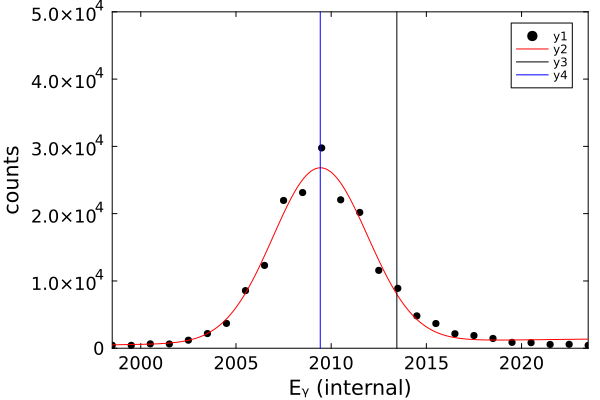

In [52]:
c2c2_p3_mean = 2013.5
c2c2_x1low,c2c2_x1high=c2c2_p3_mean-15,c2c2_p3_mean+10; ylow,yhigh=0,5e4
c2c2_param1=[100,0.05,2e5,c2c2_p3_mean,1.0]

c2c2_p3,c2c2_s3,f=PhotopeakFit.gaussianfit(kc2c2,c2c2_x1low,c2c2_x1high,c2c2_param1)

for (i,val) in enumerate(c2c2_p3)
    println("P$i = ",val,"($(c2c2_s1[i]))")
end
println("Calibrated - Expected = $(c2c2_p3[4] - kliterature[3]) keV")

scatter(kc2c2[:,1],kc2c2[:,2],xlims=(c2c2_x1low,c2c2_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c2_p3),c2c2_x1low,c2c2_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c2_p3[4]],lc=:blue)

## Crystal 11 (c2c3)

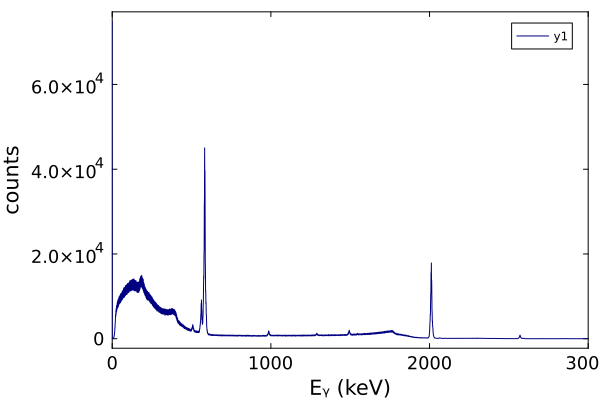

In [53]:
kc2c3 = Matrix(select(data[data.y_center .== 11.5, :], Not(:y_center)))

plot(kc2c3[:,1],kc2c3[:,2],xlims=(0,3000),xlabel="Eᵧ (keV)")

### Peak 1 (565)

P1 = -23303.92227918821(16440.736639678755)
P2 = 47.931042024269374(29.15122208348508)
P3 = 28277.892198277685(3805.783061952331)
P4 = 561.7292429411453(0.22875323472055958)
P5 = 2.3295126656486222(0.2697672819983353)
Calibrated - Expected = -3.0607570588546196 keV


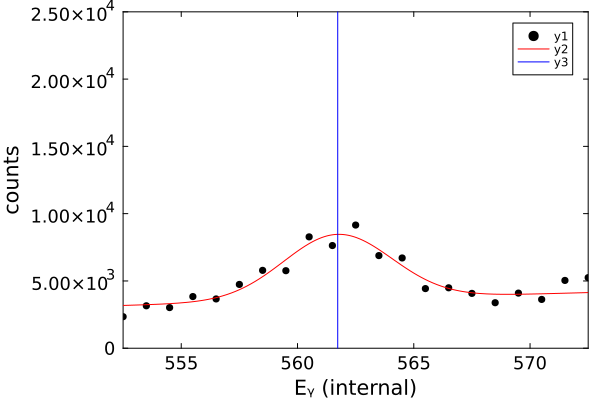

In [54]:
c2c3_p1_mean = 562.5
c2c3_x1low,c2c3_x1high=c2c3_p1_mean-10,c2c3_p1_mean+10; ylow,yhigh=0,2.5e4
c2c3_param1=[100,0.05,2e5,c2c3_p1_mean,1.0]

c2c3_p1,c2c3_s1,f=PhotopeakFit.gaussianfit(kc2c3,c2c3_x1low,c2c3_x1high,c2c3_param1)

for (i,val) in enumerate(c2c3_p1)
    println("P$i = ",val,"($(c2c3_s1[i]))")
end
println("Calibrated - Expected = $(c2c3_p1[4] - kliterature[1]) keV")

scatter(kc2c3[:,1],kc2c3[:,2],xlims=(c2c3_x1low,c2c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c3_p1),c2c3_x1low,c2c3_x1high,lc=:red)
vline!([c2c3_p1[4]],lc=:blue)

### Peak 2 (586)

P1 = 105996.90336360378(16440.736639678755)
P2 = -169.16566147088113(29.15122208348508)
P3 = 241334.6082748587(3805.783061952331)
P4 = 582.9889640659443(0.22875323472055958)
P5 = 2.8745926409360036(0.2697672819983353)
Calibrated - Expected = -3.0210359340557034 keV


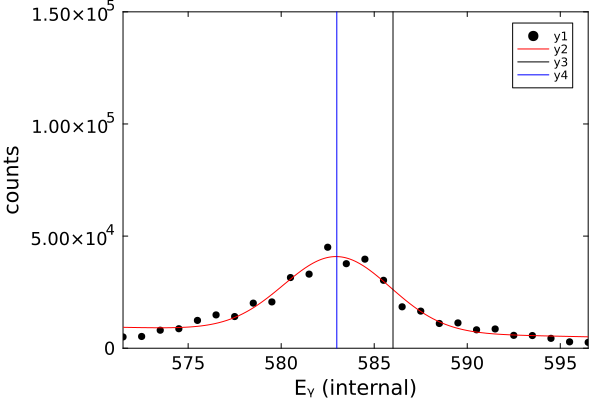

In [55]:
c2c3_p2_mean = 586.5
c2c3_x1low,c2c3_x1high=c2c3_p2_mean-15,c2c3_p2_mean+10; ylow,yhigh=0,1.5e5
c2c3_param1=[100,0.05,2e5,c2c3_p2_mean,1.0]

c2c3_p2,c2c3_s2,f=PhotopeakFit.gaussianfit(kc2c3,c2c3_x1low,c2c3_x1high,c2c3_param1)

for (i,val) in enumerate(c2c3_p2)
    println("P$i = ",val,"($(c2c3_s1[i]))")
end
println("Calibrated - Expected = $(c2c3_p2[4] - kliterature[2]) keV")

scatter(kc2c3[:,1],kc2c3[:,2],xlims=(c2c3_x1low,c2c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c3_p2),c2c3_x1low,c2c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c3_p2[4]],lc=:blue)

### Peak 3 (2013)

P1 = 23895.694853465193(16440.736639678755)
P2 = -10.787850038770728(29.15122208348508)
P3 = 118540.49244056335(3805.783061952331)
P4 = 2011.0463310387038(0.22875323472055958)
P5 = 3.450640079227741(0.2697672819983353)
Calibrated - Expected = -2.403668961296262 keV


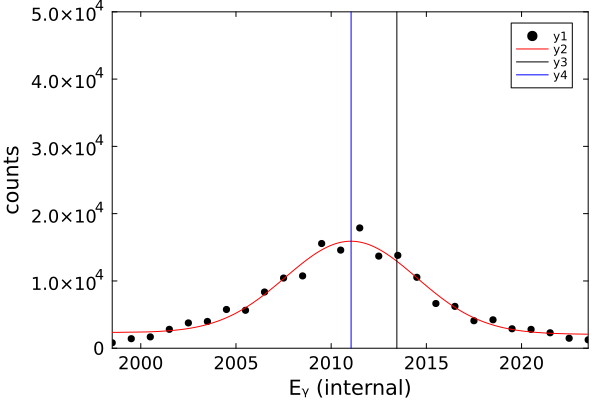

In [56]:
c2c3_p3_mean = 2013.5
c2c3_x1low,c2c3_x1high=c2c3_p3_mean-15,c2c3_p3_mean+10; ylow,yhigh=0,5e4
c2c3_param1=[100,0.05,2e5,c2c3_p3_mean,1.0]

c2c3_p3,c2c3_s3,f=PhotopeakFit.gaussianfit(kc2c3,c2c3_x1low,c2c3_x1high,c2c3_param1)

for (i,val) in enumerate(c2c3_p3)
    println("P$i = ",val,"($(c2c3_s1[i]))")
end
println("Calibrated - Expected = $(c2c3_p3[4] - kliterature[3]) keV")

scatter(kc2c3[:,1],kc2c3[:,2],xlims=(c2c3_x1low,c2c3_x1high),seriestype=:stepmid,ylims=(ylow,yhigh))
plot!(e->f(e,c2c3_p3),c2c3_x1low,c2c3_x1high,lc=:red)
vline!(kliterature,lc=:black)
vline!([c2c3_p3[4]],lc=:blue)

## Clover 2 Areas

In [57]:
c2_areas = [(c2c0_p1[3] + c2c1_p1[3] + c2c2_p1[3] + c2c3_p1[3]), 
            (c2c0_p2[3] + c2c1_p2[3] + c2c2_p2[3] + c2c3_p2[3]), 
            (c2c0_p3[3] +c2c1_p3[3] + c2c2_p3[3] + c2c3_p3[3])]

c2_σareas = [(c2c0_s1[3]^2 + c2c1_s1[3]^2 + c2c2_s1[3]^2 + c2c3_s1[3]^2)^(1/2),
             (c2c0_s2[3]^2 + c2c1_s2[3]^2 + c2c2_s2[3]^2 + c2c3_s2[3]^2)^(1/2),
             (c2c0_s3[3]^2 + c2c1_s3[3]^2 + c2c2_s3[3]^2 + c2c3_s3[3]^2)^(1/2)]

3-element Vector{Float64}:
  7511.718061866748
 34762.36721162444
 15610.518886792595

# Analysis

## Asymmetries

### $$ \frac{N_0 - N_1}{N_0 + N_1} $$

In [58]:
asymm_01 = (c0_areas .- c1_areas) ./ (c0_areas .+ c1_areas)

3-element Vector{Float64}:
 0.819467233687705
 0.8199102261770281
 0.8127073851005624

#### Errors

In [59]:
err_01 = (((c0_σareas .^ 2) .* (((2 .* c1_areas) ./ ((c0_areas .+ c1_areas) .^2)) .^ 2)) .+ ((c1_σareas .^ 2) .* (((-2 .* c0_areas) ./ ((c0_areas .+ c1_areas) .^2)) .^ 2))) .^ (0.5)

3-element Vector{Float64}:
 0.0042390785443566946
 0.004533523825903341
 0.004904989845794536

#### Plot

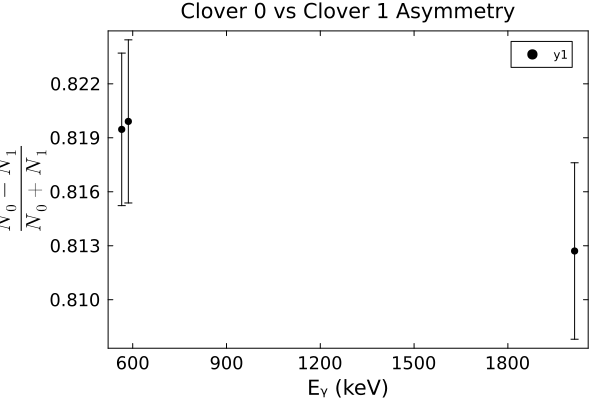

In [60]:
scatter(kliterature, asymm_01, yerr=err_01, xlabel="Eᵧ (keV)",ylabel=L"\frac{N_0 - N_1}{N_0 + N_1}")
#hline!([0])
title!("Clover 0 vs Clover 1 Asymmetry")

#### Polarization

- figure out what to use for N_0 plus and minus

In [ ]:
R_fun(A, B, C, D) = (A .* D) ./ (B .* C)


err(A, B, C, D, σA, σB, σC, σD) = ((((σA) .^2) .* ((D ./ (B .* C)) .^ 2)) .+ (((σB) .^ 2) .* (((-A .* D) ./ ((B .^ 2) .* C)) .^ 2)) .+ (((σC) .^2) .* (((-A .* D) ./ (B .* (C .^ 2))) .^2)) .+ (((σD) .^ 2) .* ((A ./ (B .* C)) .^ 2))) .^ (0.5)

R = R_fun(N_0_plus, N_1_plus, N_0_minus, N_1_minus)
println(R)

error_r = err(N_0_plus, N_1_plus, N_0_minus, N_1_minus, N_0_σplus, N_1_σplus, N_0_σminus, N_1_σminus)
println(error_r)

### $$ \frac{N_2 - N_1}{N_2 + N_1} $$

In [62]:
asymm_21 = (c2_areas .- c1_areas) ./ (c2_areas .+ c1_areas)

3-element Vector{Float64}:
 0.7720815336143786
 0.7845113373787184
 0.7749715957673403

#### Errors

In [63]:
err_21 = (((c2_σareas .^ 2) .* (((2 .* c1_areas) ./ ((c2_areas .+ c1_areas) .^2)) .^ 2)) .+ ((c1_σareas .^ 2) .* (((-2 .* c2_areas) ./ ((c2_areas .+ c1_areas) .^2)) .^ 2))) .^ (0.5)

3-element Vector{Float64}:
 0.008034967963380955
 0.006306387487963307
 0.0068102430416202364

#### Plots

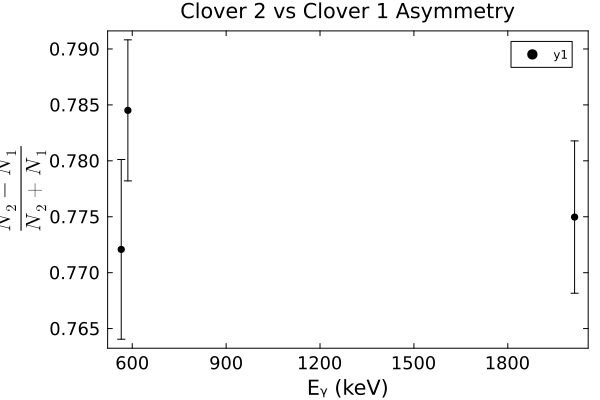

In [64]:
scatter(kliterature, asymm_21, yerr=err_21, xlabel="Eᵧ (keV)",ylabel=L"\frac{N_2 - N_1}{N_2 + N_1}")
#hline!([0])
title!("Clover 2 vs Clover 1 Asymmetry")

## Polarization

- Ask Madurga about this

### Ratios

In [72]:
ratio = c1_areas ./ c0_areas
println(ratio)

err_rat = (((c1_σareas .^ 2) .* ((1 ./ c0_areas) .^ 2)) .+ ((c0_σareas .^ 2) .* ((-c1_areas ./ (c0_areas .^2)) .^ 2))) .^ (0.5)
println(err_rat)

[0.09922287303101925, 0.09895530627424143, 0.10332203445458307]
[0.002561020066894873, 0.00273757463029528, 0.0029854699220199154]


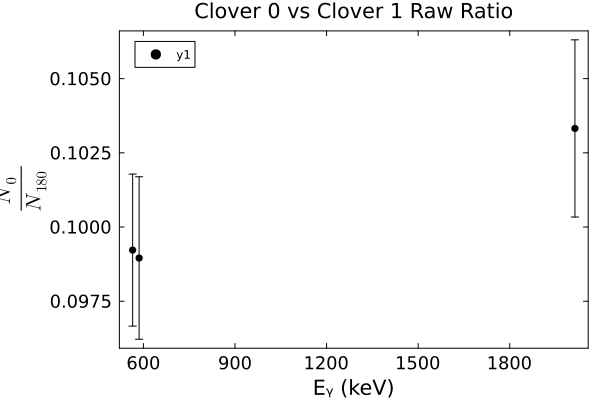

In [75]:
q = scatter(kliterature, ratio, yerr=err_rat,
    xlabel = "Eᵧ (keV)",
    ylabel = L"\frac{N_0}{N_{180}}",
    title = "Clover 0 vs Clover 1 Raw Ratio"
)

In [74]:
N_565 = ratio[1]
println(N_565)
N_σ565 = err_rat[1]
println(N_σ565)

N_586 = ratio[2]
println(N_586)
N_σ586 = err_rat[2]
println(N_σ586)

0.09922287303101925
0.002561020066894873
0.09895530627424143
0.00273757463029528


In [76]:
# quadratic gices two answers, this one gives answers too large
#P_plus = ((9 .* (N_565 .+ N_586)) .+ (3 .* (((N_565 .^ 2) .+ (34 .* N_565 .* N_586) .+ (N_586 .^ 2)) .^ 0.5))) ./ (4 .* (N_565 .- N_586))
#println(P_plus)

# This one gives an acceptable value
P_plus = ((9 .* (N_565 .+ N_586)) .- (3 .* (((N_565 .^ 2) .+ (34 .* N_565 .* N_586) .+ (N_586 .^ 2)) .^ 0.5))) ./ (4 .* (N_565 .- N_586))
# println(P_plus)

P_percent = P_plus .* 100
println(P_percent)


err_P =  P_plus .* (((N_σ565 .^2) ./ N_565) .+ ((N_σ586 .^2) ./ N_586)) .^ 0.5
println(err_P .* 100)


# Percent error on Polarization amount
Percent = (err_P ./ P_plus) .* 100

0.13501328250514225
0.0016079411641453938


1.190950352669303

Polarization value is 0.13% $\pm$ 0.0016%
- is this too small??